In [4]:
import pandas as pd
import numpy as np
import json
import os
import pickle
import cps_utils as cpsu
import matplotlib.pyplot as plt
import plotly.express as px
from ogcore import output_plots as op

In [5]:
# Set directories
cur_dir = (
    "/Users/richardevans/Docs/Economics/OSE/Federal/CRFB2025/SS_MaxBen/code"
)
data_dir = os.path.join(cur_dir, "..", "data")
base_post_dir = os.path.join(cur_dir, "OUTPUT_BASELINE_POSTOBBBA")
ref_init_dir = os.path.join(cur_dir, "OUTPUT_SS_MAXBEN")
ref_2046_dir = os.path.join(cur_dir, "OUTPUT_SS_MAXBEN_2046")
ref_2056_dir = os.path.join(cur_dir, "OUTPUT_SS_MAXBEN_2056")

## 1. CPS data work

In [6]:
cps_path = os.path.join(data_dir, "asecpub23csv", "hhpub23.csv")
df = pd.read_csv(cps_path, dtype=str)
# keep just variables of interest
df = df[["HSSVAL", "HSUP_WGT", "HRHTYPE"]]

# cast HSSVAL as float
df["HSSVAL"] = df["HSSVAL"].astype(float)
# cast HSUP_WGT as float
df["HSUP_WGT"] = df["HSUP_WGT"].astype(float)

df = df[df["HSSVAL"] > 0]
# create indicator for married or single
df["married"] = df["HRHTYPE"].isin(["1", "2"])

cutoffs = cpsu.show_weighted_percentile_cutoffs(df)
df = cpsu.add_weighted_percentile_groups(df)

# Find fraction of SS benefits that accrue to households above a benefit cap
# CONSTANTS
BENEFIT_CAP_COUPLES = 100_000  # Nominal cap on benefits
BENEFIT_CAP_SINGLES = 67_000  # Nominal cap on benefits
BENEFIT_GROWTH_RATE = 0.04  # Assumed annual growth rate in nominal benefits
END_YEAR = 2100  # final year to grow out to

out_dict = {
    "year": [],
    "0-25": [],
    "25-50": [],
    "50-70": [],
    "70-80": [],
    "80-90": [],
    "90-99": [],
    "99-100": [],
    "total_capped_fraction": []
}
for y in range(2023, END_YEAR + 1):
    # inflation HSSVAL
    df.loc[:, "HSSVAL"] *= (1 + BENEFIT_GROWTH_RATE)

    df["capped"] = np.where(
        df["married"],
        np.maximum(df["HSSVAL"] - BENEFIT_CAP_COUPLES, 0),
        np.maximum(df["HSSVAL"] - BENEFIT_CAP_SINGLES, 0),
    )
    total_benefits = (df.HSSVAL * df.HSUP_WGT).sum()
    total_capped = (df["capped"] * df["HSUP_WGT"]).sum()

    # group by percentile group and sum total HSSVAL and capped
    df_grouped = (
        df.groupby("pctile_group", observed=False)[
            ["pctile_group", "HSSVAL", "HSUP_WGT", "capped"]
        ]
        .apply(
            lambda x: pd.Series(
                {
                    "total_SS": cpsu.weighted_sum(x["HSSVAL"], x["HSUP_WGT"]),
                    "capped_SS": cpsu.weighted_sum(x["capped"], x["HSUP_WGT"]),
                }
            )
        )
        .reset_index()
    )

    df_grouped["fraction_capped"] = (
        df_grouped["capped_SS"] / df_grouped["total_SS"]
    )

    out_dict["year"].append(y)
    for pct in df_grouped.pctile_group.unique():
        out_dict[pct].append(
            df_grouped[df_grouped.pctile_group == pct][
                "fraction_capped"
            ].values[0]
        )
    out_dict["total_capped_fraction"].append(total_capped / total_benefits)

    # turn to df
out_df = pd.DataFrame.from_dict(out_dict)
# find year where 25% of benefits are capped
# year_25_capped = out_df[out_df["total_capped_fraction"] >= 0.25]["year"].min()
year_25_capped = 2055
print("25% of benefits are capped in year:", year_25_capped)

# save to JSON for use in OG-USA calibration of replacement_rate_adjust
a = out_df[out_df["year"] <= year_25_capped][["0-25", "25-50","50-70", "70-80", "80-90", "90-99", "99-100"]].values
# # add to a: have values linearly go back down to zero over next 25 years
# for i in range(1, 26):
#     a = np.append(a, (a[-1, :] * (1 - i / 25)).reshape(1, 7), axis=0)
# append 3 columns with same values as last column
# this is because we are using OG-Core with J=10
a = np.append(a, np.tile(a[:, -1].reshape(a.shape[0], 1), (1, 3)), axis=1)
a_dict = {"replacement_rate_adjust": a.tolist()}
# do one minus the fraction capped to get the replacement_rate_adjust parameter
a = 1 - a
# save to json
with open("maxben_replacement_rate_adjust.json", "w") as f:
    json.dump(a_dict, f)

# plot by year and percentile

fig = px.line(
    out_df,
    x="year",
    y=["0-25", "25-50", "50-70", "70-80", "80-90", "90-99", "99-100"],
    title="Fraction of SS Benefits Exceeding Cap by Percentile",
)
fig.show()

Weighted Percentile Cutoffs:
25th percentile: 14280.59
50th percentile: 22000.00
70th percentile: 29664.39
80th percentile: 36000.00
90th percentile: 45385.32
99th percentile: 70000.00
25% of benefits are capped in year: 2055


In [7]:
a.shape

(33, 10)

In [12]:
out_df.keys()

Index(['year', '0-25', '25-50', '50-70', '70-80', '80-90', '90-99', '99-100',
       'total_capped_fraction'],
      dtype='object')

In [13]:
out_df["total_capped_fraction"].shape

(78,)

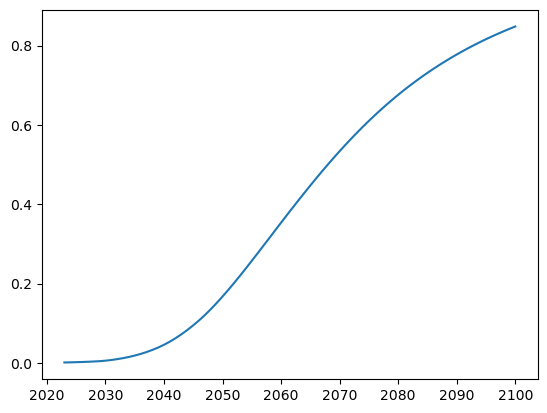

In [6]:
plt.plot(np.arange(2023, 2101), out_df["total_capped_fraction"])

In [13]:
# Show the year and total_capped_fraction variables for year = 2055
print(out_df[(out_df["year"] >= 2050) & (out_df["year"] <= 2058)][["year", "total_capped_fraction"]])

    year  total_capped_fraction
27  2050               0.167174
28  2051               0.184145
29  2052               0.201726
30  2053               0.219801
31  2054               0.238357
32  2055               0.257261
33  2056               0.276270
34  2057               0.295457
35  2058               0.314738


## 2. Simulation with initial OUTPUT_SS_MAXBEN reform

In [ ]:
# Generate plot of average percent reduction from reform of initial retiree
# benefits
p_base_post_path = os.path.join(base_post_dir, "model_params.pkl")
tpi_vars_base_post_path = os.path.join(base_post_dir, "TPI", "TPI_vars.pkl")
p_base_post = pickle.load(open(p_base_post_path, "rb"))
tpi_vars_base_post = pickle.load(open(tpi_vars_base_post_path, "rb"))

p_ref_path = os.path.join(ref_init_dir, "model_params.pkl")
tpi_vars_ref_path = os.path.join(ref_init_dir, "TPI", "TPI_vars.pkl")
p_ref = pickle.load(open(p_ref_path, "rb"))
tpi_vars_ref = pickle.load(open(tpi_vars_ref_path, "rb"))

print("p_ref keys:")
print(p_ref.keys())
print("")
print("tpi_vars_ref keys:")
print(tpi_vars_ref.keys())

p_ref keys:
dict_keys(['frisch', 'g_y_annual', 'S', 'J', 'T', 'M', 'I', 'lambdas', 'e', 'starting_age', 'ending_age', 'constant_demographics', 'beta_annual', 'sigma', 'alpha_c', 'gamma', 'gamma_g', 'epsilon', 'io_matrix', 'Z', 'delta_annual', 'delta_g_annual', 'ltilde', 'world_int_rate_annual', 'initial_foreign_debt_ratio', 'zeta_D', 'zeta_K', 'tG1', 'tG2', 'alpha_T', 'alpha_G', 'alpha_I', 'alpha_bs_T', 'alpha_bs_G', 'alpha_bs_I', 'rho_G', 'alpha_RM_1', 'alpha_RM_T', 'g_RM', 'debt_ratio_ss', 'initial_debt_ratio', 'initial_Kg_ratio', 'r_gov_scale', 'r_gov_shift', 'cit_rate', 'c_corp_share_of_assets', 'adjustment_factor_for_cit_receipts', 'inv_tax_credit', 'tau_c', 'delta_tau_annual', 'h_wealth', 'm_wealth', 'p_wealth', 'tau_bq', 'tau_payroll', 'chi_b', 'chi_n', 'ubi_growthadj', 'ubi_nom_017', 'ubi_nom_1864', 'ubi_nom_65p', 'ubi_nom_max', 'eta', 'eta_RM', 'zeta', 'use_zeta', 'constant_rates', 'zero_taxes', 'analytical_mtrs', 'age_specific', 'retirement_age', 'pension_system', 'tau_p', 'i

In [ ]:
# Collapse list of lists p_ref.lambdas into list of scalars
lambdas = [item for sublist in p_ref.lambdas for item in sublist]
# Format every element in lambdas as a float
lambdas = [float(x) for x in lambdas]
print(lambdas)

[0.25, 0.25, 0.2, 0.1, 0.1, 0.09, 0.005, 0.004, 0.0009, 0.0001]


In [25]:
omega = p_ref.omega
print("omega type is:", type(omega))
print("omega shape is:", omega.shape)

omega type is: <class 'numpy.ndarray'>
omega shape is: (400, 80)


In [28]:
delta_q = 0.025
delta_a = 1 - (1 - delta_q) ** 4
print("delta_a is:", delta_a)
delta1 = 1 - (1 - delta_a) ** (30)
print("delta1 is:", delta1)
delta2 = 1 - (1 - delta_q) ** (120)
print("delta2 is:", delta2)

rho_a = 0.95
rho = rho_a ** (30)
print("rho is:", rho)


delta_a is: 0.09631210937500012
delta1 is: 0.9520759090358631
delta2 is: 0.952075909035863
rho is: 0.21463876394293727


## Create plots

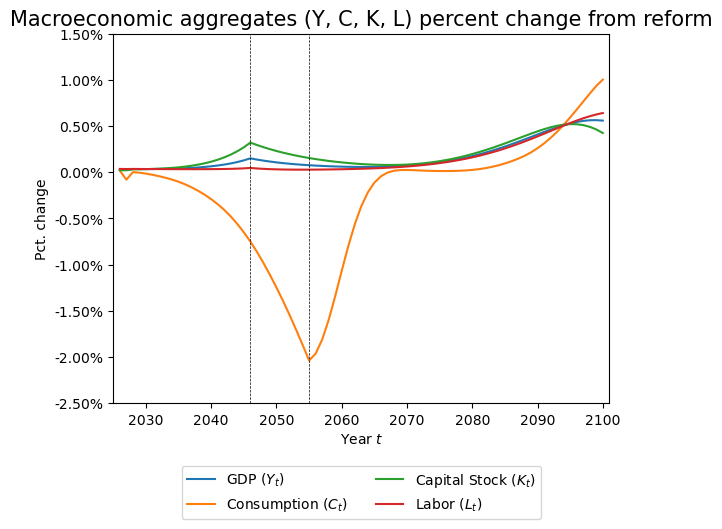

In [19]:
# GDP, K, C, L
fig_YCKL = op.plot_aggregates(
    tpi_vars_base_post,
    p_base_post,
    tpi_vars_ref,
    p_ref,
    var_list=["Y", "C", "K", "L"],
    plot_type="pct_diff",
    stationarized=True,
    num_years_to_plot=75,
    start_year=2026,
    vertical_line_years=[p_ref.start_year + p_ref.tG1, 2055],
    plot_title=(
        "Macroeconomic aggregates (Y, C, K, L) percent change from reform"
    )
)

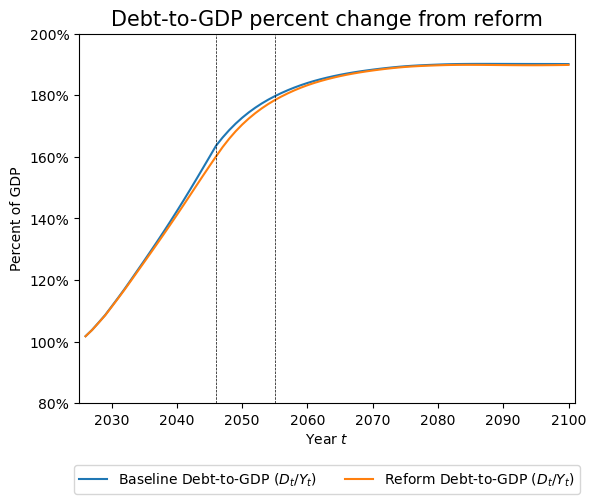

In [20]:
# Plot debt-to-GDP
fig_DY = op.plot_gdp_ratio(
    tpi_vars_base_post,
    p_base_post,
    tpi_vars_ref,
    p_ref,
    var_list=["D"],
    plot_type="levels",
    num_years_to_plot=75,
    start_year=2026,
    vertical_line_years=[p_ref.start_year + p_ref.tG1, 2055],
    plot_title="Debt-to-GDP percent change from reform"
)

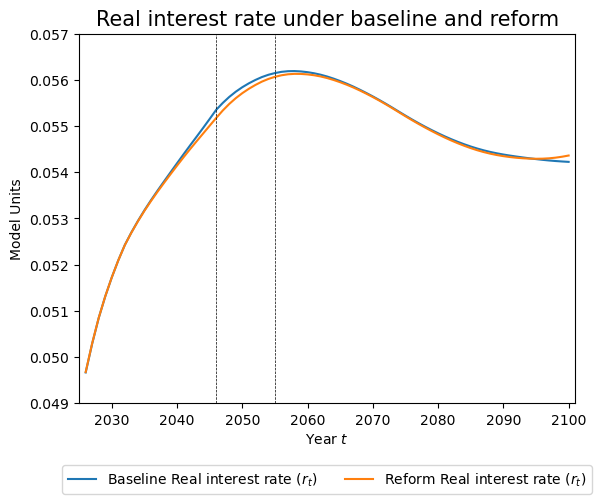

In [21]:
# interest rates r
fig_r = op.plot_aggregates(
    tpi_vars_base_post,
    p_base_post,
    tpi_vars_ref,
    p_ref,
    var_list=["r"],
    plot_type="levels",
    num_years_to_plot=75,
    start_year=2026,
    vertical_line_years=[p_ref.start_year + p_ref.tG1, 2055],
    plot_title=(
        "Real interest rate under baseline and reform"
    )
)

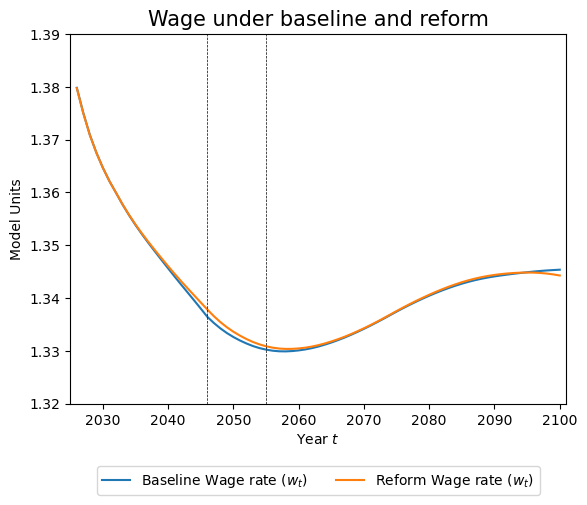

In [24]:
# wage w
fig_w = op.plot_aggregates(
    tpi_vars_base_post,
    p_base_post,
    tpi_vars_ref,
    p_ref,
    var_list=["w"],
    plot_type="levels",
    num_years_to_plot=75,
    start_year=2026,
    vertical_line_years=[p_ref.start_year + p_ref.tG1, 2055],
    plot_title=(
        "Wage under baseline and reform"
    )
)

In [40]:
## SS Trust Fund Balance, recreate Figure "Social Security Trust Fund Balance
# Ratios" from the Aug. 2024 "CBO's 2024 Long-term Provections for Social
# Security" doc
path_to_sstf_ratios = os.path.join(data_dir, "60392-Additional-Info.xlsx")
sstf_ratios_fy_df = pd.read_excel(
    path_to_sstf_ratios,
    sheet_name="7. TF Balances and Deficits",
    names=[
        "year", "OASI_primdef", "OASI_bal", "DI_primdef", "DI_bal", "intrate"
    ],
    usecols="A:C,E:G",
    dtype={
        "year": int,
        "OASI_primdef": float,
        "OASI_bal": float,
        "DI_primdef": float,
        "DI_bal": float,
        "intrate": float
    },
    skiprows=9,
    nrows=11,
    na_values=["n.a."]
)
print("sstf_ratios_fy_df:")
print(sstf_ratios_fy_df)

sstf_ratios_cy_df = pd.read_excel(
    path_to_sstf_ratios,
    sheet_name="7. TF Balances and Deficits",
    names=[
        "year", "OASI_primdef", "OASI_bal", "DI_primdef", "DI_bal", "intrate"
    ],
    usecols="A:C,E:G",
    dtype={
        "year": int,
        "OASI_primdef": float,
        "OASI_bal": float,
        "DI_primdef": float,
        "DI_bal": float,
        "intrate": float
    },
    skiprows=21,
    nrows=64,
    na_values=["n.a."]
)
print("")
print("sstf_ratios_cy_df:")
print(sstf_ratios_cy_df)

# Create sstf_ratios_df that appends sstf_ratios_cy_df at the bottom of
# sstf_ratios_fy_df
sstf_ratios_df = pd.concat(
    [sstf_ratios_fy_df, sstf_ratios_cy_df], ignore_index=True
)
print("")
print("sstf_ratios_df:")
print(sstf_ratios_df)

print("")
print("sstf_ratios_df rows 8-14:")
print(sstf_ratios_df.iloc[8:15])

# For row index values 9 and above in the OASI_bal column, set values to the
# previous row's value plus the OASI_primdef value for that row
for row in range(9,len(sstf_ratios_df)):
    sstf_ratios_df.loc[row, "OASI_bal"] = (
        sstf_ratios_df.loc[row - 1, "OASI_bal"]
        + sstf_ratios_df.loc[row, "OASI_primdef"]
    )

print("")
print("New sstf_ratios_df rows 8-14:")
print(sstf_ratios_df.iloc[8:15])

print("")
print("sstf_ratios_df rows 35-49:")
print(sstf_ratios_df.iloc[35:50])

# For row index values 40 and above in the DI_bal column, set values to the
# previous row's value plus the DI_primdef value for that row
for row in range(40,len(sstf_ratios_df)):
    sstf_ratios_df.loc[row, "DI_bal"] = (
        sstf_ratios_df.loc[row - 1, "DI_bal"]
        + sstf_ratios_df.loc[row, "DI_primdef"]
    )

print("")
print("sstf_ratios_df rows 35-49:")
print(sstf_ratios_df.iloc[35:50])

# Created combined OASI + DI combined balance variable
sstf_ratios_df["OASI_DI_bal"] = (
    sstf_ratios_df["OASI_bal"] + sstf_ratios_df["DI_bal"]
)

sstf_ratios_fy_df:
    year  OASI_primdef  OASI_bal  DI_primdef  DI_bal  intrate
0   2024         -0.59      9.02        0.10    0.62     4.45
1   2025         -0.71      8.11        0.10    0.71     4.09
2   2026         -0.78      7.19        0.09    0.79     3.66
3   2027         -0.86      6.21        0.08    0.87     3.59
4   2028         -0.96      5.16        0.08    0.95     3.67
5   2029         -1.04      4.03        0.08    1.03     3.78
6   2030         -1.12      2.83        0.08    1.11     3.90
7   2031         -1.20      1.57        0.08    1.19     4.01
8   2032         -1.27      0.25        0.08    1.27     4.08
9   2033         -1.33       NaN        0.08    1.35     4.10
10  2034         -1.38       NaN        0.07    1.42     4.11

sstf_ratios_cy_df:
    year  OASI_primdef  OASI_bal  DI_primdef  DI_bal  intrate
0   2035         -1.37       NaN        0.07    1.53     4.11
1   2036         -1.37       NaN        0.05    1.58     4.12
2   2037         -1.36       Na

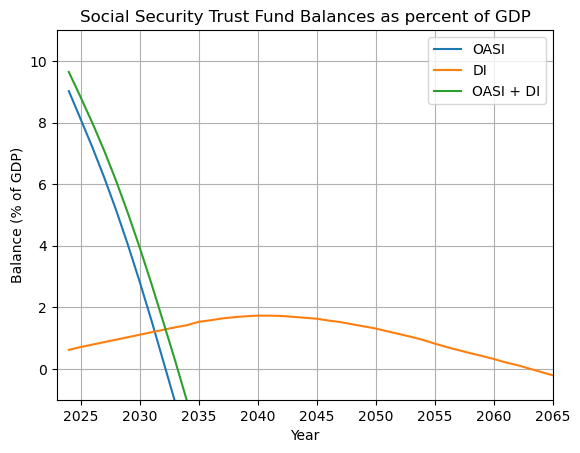

In [43]:
plt.plot(sstf_ratios_df["year"], sstf_ratios_df["OASI_bal"], label="OASI")
plt.plot(sstf_ratios_df["year"], sstf_ratios_df["DI_bal"], label="DI")
plt.plot(
    sstf_ratios_df["year"], sstf_ratios_df["OASI_DI_bal"], label="OASI + DI"
)
plt.xlabel("Year")
plt.ylabel("Balance (% of GDP)")
plt.title("Social Security Trust Fund Balances as percent of GDP")
plt.xlim(2023, 2065)
plt.ylim(-1, 11)
plt.legend()
plt.grid()
plt.show()

## Variables that we care about
Below are the variables in `tpi_vars` dictionaries that we care about
- `Y`, `D`, `K`, `L`, `C`, `I`, `agg_pension_outlays`, `total_tax_revenue`, `payroll_tax_revenue`, `r`, `w`, `b_s`, `n`, `c`

Here are the variables that we have to create
- `SS_indiv_income`

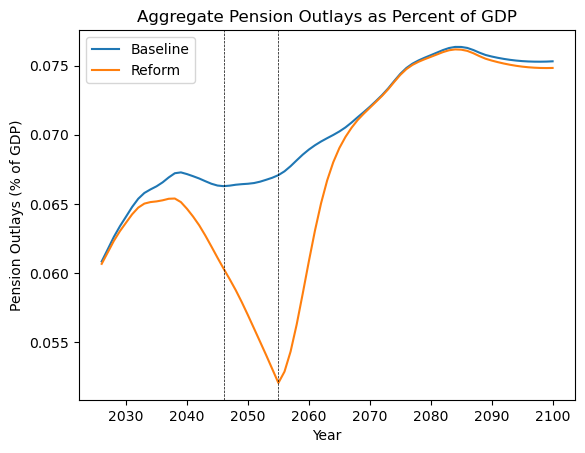

In [53]:
years_to_plot = 75
payroll_tax_rev_base_post = tpi_vars_base_post["payroll_tax_revenue"]
agg_pension_outlays_base_post = tpi_vars_base_post["agg_pension_outlays"]
primary_surplus_base_post = (
    payroll_tax_rev_base_post - agg_pension_outlays_base_post
)
Y_base_post = tpi_vars_base_post["Y"]
payroll_tax_rev_ref = tpi_vars_ref["payroll_tax_revenue"]
agg_pension_outlays_ref = tpi_vars_ref["agg_pension_outlays"]
primary_surplus_ref = payroll_tax_rev_ref - agg_pension_outlays_ref
Y_ref = tpi_vars_ref["Y"]
plt.plot(
    np.arange(p_ref.start_year, p_ref.start_year + years_to_plot),
    agg_pension_outlays_base_post[:years_to_plot] /
    Y_base_post[:years_to_plot],
    label="Baseline"
)
plt.plot(
    np.arange(p_ref.start_year, p_ref.start_year + years_to_plot),
    agg_pension_outlays_ref[:years_to_plot] /
    Y_ref[:years_to_plot],
    label="Reform"
)
plt.axvline(
    x=p_ref.start_year + p_ref.tG1, linewidth=0.5, linestyle="--", color="k"
)
plt.axvline(
    x=2055, linewidth=0.5, linestyle="--", color="k"
)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Pension Outlays (% of GDP)")
plt.title("Aggregate Pension Outlays as Percent of GDP")
# plt.grid()
plt.show()

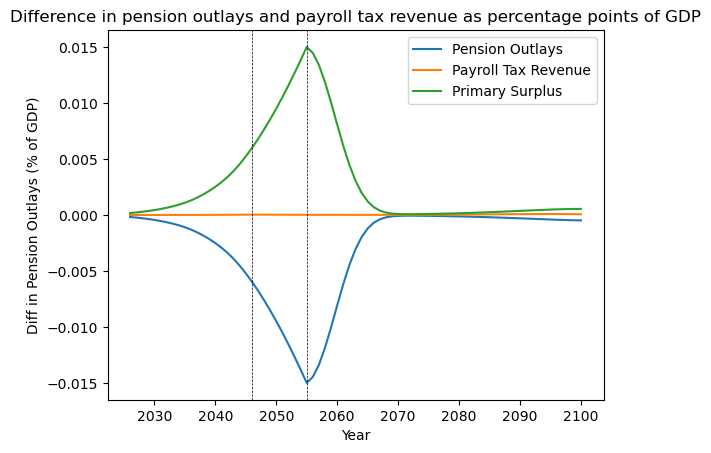

In [55]:
agg_pension_outlays_diff = (
    (agg_pension_outlays_ref / Y_ref) -
    (agg_pension_outlays_base_post / Y_base_post)
)
payroll_tax_rev_diff = (
    (payroll_tax_rev_ref / Y_ref) -
    (payroll_tax_rev_base_post / Y_base_post)
)
primary_surplus_diff = (
    (primary_surplus_ref / Y_ref) -
    (primary_surplus_base_post / Y_base_post)
)
plt.plot(
    np.arange(p_ref.start_year, p_ref.start_year + years_to_plot),
    agg_pension_outlays_diff[:years_to_plot], label="Pension Outlays"
)
plt.plot(
    np.arange(p_ref.start_year, p_ref.start_year + years_to_plot),
    payroll_tax_rev_diff[:years_to_plot], label="Payroll Tax Revenue"
)
plt.plot(
    np.arange(p_ref.start_year, p_ref.start_year + years_to_plot),
    primary_surplus_diff[:years_to_plot], label="Primary Surplus"
)
plt.axvline(
    x=p_ref.start_year + p_ref.tG1, linewidth=0.5, linestyle="--", color="k"
)
plt.axvline(
    x=2055, linewidth=0.5, linestyle="--", color="k"
)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Diff in Pension Outlays (% of GDP)")
plt.title("Difference in pension outlays and payroll tax revenue as percentage points of GDP")
# plt.grid()
plt.show()

## 3. Simulation with 2046 trigger year reform

In [58]:
# Set the parameters and TPI objects
# p_base_post_path = os.path.join(base_post_dir, "model_params.pkl")
# tpi_vars_base_post_path = os.path.join(base_post_dir, "TPI", "TPI_vars.pkl")
# p_base_post = pickle.load(open(p_base_post_path, "rb"))
# tpi_vars_base_post = pickle.load(open(tpi_vars_base_post_path, "rb"))

p_ref_2046_path = os.path.join(ref_2046_dir, "model_params.pkl")
tpi_vars_ref_2046_path = os.path.join(ref_2046_dir, "TPI", "TPI_vars.pkl")
p_ref_2046 = pickle.load(open(p_ref_2046_path, "rb"))
tpi_vars_ref_2046 = pickle.load(open(tpi_vars_ref_2046_path, "rb"))

print("p_ref_2046 keys:")
print(p_ref_2046.keys())
print("")
print("tpi_vars_ref_2046 keys:")
print(tpi_vars_ref_2046.keys())

p_ref_2046 keys:
dict_keys(['frisch', 'g_y_annual', 'S', 'J', 'T', 'M', 'I', 'lambdas', 'e', 'starting_age', 'ending_age', 'constant_demographics', 'beta_annual', 'sigma', 'alpha_c', 'gamma', 'gamma_g', 'epsilon', 'io_matrix', 'Z', 'delta_annual', 'delta_g_annual', 'ltilde', 'world_int_rate_annual', 'initial_foreign_debt_ratio', 'zeta_D', 'zeta_K', 'tG1', 'tG2', 'alpha_T', 'alpha_G', 'alpha_I', 'alpha_bs_T', 'alpha_bs_G', 'alpha_bs_I', 'rho_G', 'alpha_RM_1', 'alpha_RM_T', 'g_RM', 'debt_ratio_ss', 'initial_debt_ratio', 'initial_Kg_ratio', 'r_gov_scale', 'r_gov_shift', 'cit_rate', 'c_corp_share_of_assets', 'adjustment_factor_for_cit_receipts', 'inv_tax_credit', 'tau_c', 'delta_tau_annual', 'h_wealth', 'm_wealth', 'p_wealth', 'tau_bq', 'tau_payroll', 'chi_b', 'chi_n', 'ubi_growthadj', 'ubi_nom_017', 'ubi_nom_1864', 'ubi_nom_65p', 'ubi_nom_max', 'eta', 'eta_RM', 'zeta', 'use_zeta', 'constant_rates', 'zero_taxes', 'analytical_mtrs', 'age_specific', 'retirement_age', 'pension_system', 'tau_p

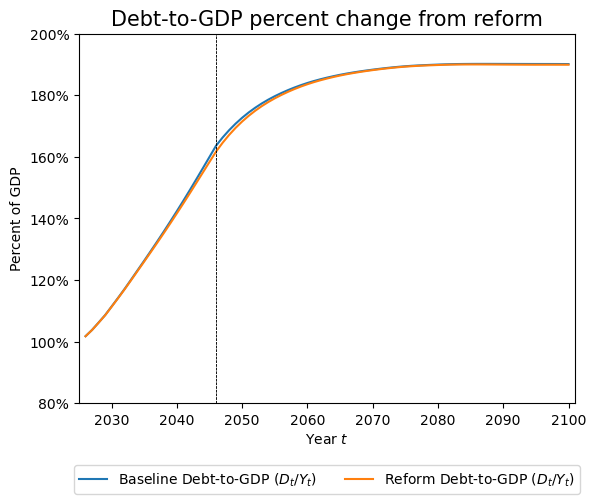

In [ ]:
# Plot debt-to-GDP
fig_DY = op.plot_gdp_ratio(
    tpi_vars_base_post,
    p_base_post,
    tpi_vars_ref_2046,
    p_ref_2046,
    var_list=["D"],
    plot_type="levels",
    num_years_to_plot=75,
    start_year=2026,
    vertical_line_years=[p_ref_2046.start_year + p_ref_2046.tG1, 2046],
    plot_title="Debt-to-GDP percent change from reform"
)

In [61]:
DY_base_post = tpi_vars_base_post["D"] / tpi_vars_base_post["Y"]
DY_ref_2046 = tpi_vars_ref_2046["D"] / tpi_vars_ref_2046["Y"]
print("DY_base_post in 2046:", DY_base_post[p_ref_2046.tG1])
print("DY_ref_2046 in 2046:", DY_ref_2046[p_ref_2046.tG1])
print(
    "Difference is:",
    DY_ref_2046[p_ref_2046.tG1] - DY_base_post[p_ref_2046.tG1]
)

DY_base_post in 2046: 1.6358508313697555
DY_ref_2046 in 2046: 1.6167312502099993
Difference is: -0.019119581159756205
